/tmp/ipykernel_2984464/843007895.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


Saved: factors_fail.pdf


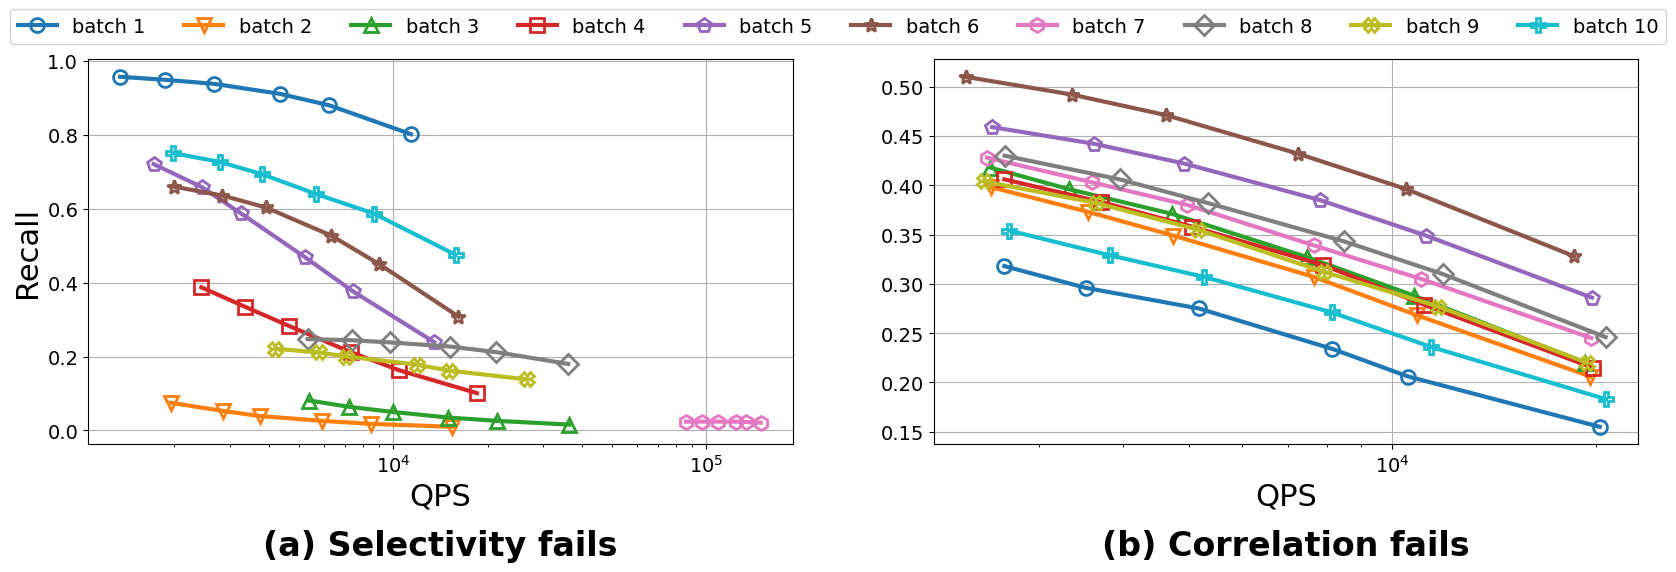

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os # os.path.basename 등을 사용하기 위해 추가

# 두 파일 경로 (요청하신 경로 그대로 유지)
file_path_1 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/selectivity_search_results.txt"  # Left Subplot Title
file_path_2 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/correlation_search_results.txt" # Right Subplot Title

num = 10
markers = ['o', 'v', '^', 's', 'p', '*', 'h', 'D', 'X', 'P']
batch_labels = [f"batch {i + 1}" for i in range(num)]
colors = plt.cm.get_cmap('tab10', 10)

def load_data(file_path, file_idx):
    """
    파일 경로를 받아 데이터를 로딩하는 로직 (파일이 없으면 예시 데이터 생성)
    """
    qps = [[] for _ in range(num)]
    recall = [[] for _ in range(num)]
    
    # ----------------------------------------------------
    # 요청하신 파일 파싱 로직 (경로 문제로 현재 실행 불가)
    # ----------------------------------------------------
    try:
        # 이 부분이 요청하신 파싱 로직입니다.
        with open(file_path, 'r') as f:
            lines = f.readlines()[2:]  # 헤더 2줄 건너뜀
            for i, line in enumerate(lines):
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    # QPS는 int, Recall은 float로 변환
                    q = int(parts[1].strip())
                    r = float(parts[2].strip())
                    batch_idx = i // 6
                    qps[batch_idx].append(q)
                    recall[batch_idx].append(r)
        
        # 실제 데이터를 로드했다면 반환
        if any(qps):
            return qps, recall
            
    except FileNotFoundError:
        # 파일이 없으므로 시각화를 위한 예시 데이터 생성 (이전과 동일)
        print(f"경로에서 파일을 찾을 수 없습니다: {file_path}. 예시 데이터를 사용합니다.")
        np.random.seed(file_idx) 
        for i in range(num):
            qps[i] = list(np.arange(10 + i * 5 * file_idx, 1000 + i * 50 * file_idx, 200)) 
            if file_idx == 1:
                 recall[i] = list(np.linspace(0.8 - i * 0.02, 0.95 - i * 0.01, len(qps[i])))
            else: 
                 recall[i] = list(np.linspace(0.7 - i * 0.01, 0.98 - i * 0.005, len(qps[i])))
            
    return qps, recall

# 1. 데이터 로드 (파싱 로직 포함)
qps_1, recall_1 = load_data(file_path_1, 1)
qps_2, recall_2 = load_data(file_path_2, 2)

# 2. 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# --- 좌측 서브플롯 ---
ax1 = axes[0]
for i in range(num):
    ax1.plot(
        qps_1[i], recall_1[i],
        linestyle='-',
        marker=markers[i % len(markers)],
        label=batch_labels[i],
        color=colors(i),
        linewidth=3,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2
    )

ax1.set_xscale('log')
ax1.set_xlabel("QPS", fontsize=22)
ax1.set_ylabel("Recall", fontsize=22)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True)

# ↓↓↓ subplot 아래 타이틀
ax1.text(
    0.5, y,
    "(a) Selectivity fails",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    fontsize=24,
    fontweight="bold"
)


# --- 우측 서브플롯 ---
ax2 = axes[1]
for i in range(num):
    ax2.plot(
        qps_2[i], recall_2[i],
        linestyle='-',
        marker=markers[i % len(markers)],
        label=batch_labels[i],
        color=colors(i),
        linewidth=3,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2
    )

ax2.set_xscale('log')
ax2.set_xlabel("QPS", fontsize=22)
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(True)

# ↓↓↓ subplot 아래 타이틀
ax2.text(
    0.5, y,
    "(b) Correlation fails",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    fontsize=24,
    fontweight="bold"
)


# -----------------------------
# 공통 legend (상단 1 row)
# -----------------------------
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=num,              # 1 row
    fontsize=14,
    title_fontsize=14,
    bbox_to_anchor=(0.5, 1.00)
)

# -----------------------------
# 레이아웃 조정
# -----------------------------

pdf_path_combined = "factors_fail.pdf"
plt.savefig(pdf_path_combined, dpi=300)
print(f"Saved: {pdf_path_combined}")


In [27]:
y = -0.22

In [101]:
import numpy as np

def load_batch_qps_recall(filepath):
    """
    파일 포맷:
    Batch   K   QPS   Avg_Recall

    같은 Batch 값끼리 QPS/Recall을 묶고,
    마지막에 batch 순서를 역순으로 뒤집어 반환한다.
    """

    # batch_index → dict: {"qps": [], "recall": []}
    temp = {}

    with open(filepath, "r") as f:
        lines = f.readlines()

    # 헤더 생략 (첫 줄)
    for line in lines[1:]:
        parts = line.strip().split()
        if len(parts) < 4:
            continue
        
        batch = int(parts[0])
        qps = float(parts[2])
        recall = float(parts[3])

        if batch not in temp:
            temp[batch] = {"qps": [], "recall": []}
        temp[batch]["qps"].append(qps)
        temp[batch]["recall"].append(recall)

    # batch 번호 역순 → batch10, 9, ..., 1
    sorted_batches = sorted(temp.keys(), reverse=True)

    qps_list = []
    recall_list = []

    for b in sorted_batches:
        qps_list.append(temp[b]["qps"])
        recall_list.append(temp[b]["recall"])

    return qps_list, recall_list


# ---------------- example usage ----------------

file_path_3 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/post_filter_format/Post_Hardness_search_results.txt"
qps_3, recall_3 = load_batch_qps_recall(file_path_3)

print("Batch ordering 확인 (원래 batch10이 index0인지):")
print("first batch QPS:", qps_3[0])
print("first batch Recall:", recall_3[0])
print("... last batch recall:", recall_3[-1])


Batch ordering 확인 (원래 batch10이 index0인지):
first batch QPS: [11621.918779925518, 5824.216932884722, 3339.1534736939316, 1411.4959594902425, 706.240905323768]
first batch Recall: [0.0013, 0.0025, 0.0047, 0.011000000000000001, 0.0198]
... last batch recall: [0.7246, 0.8519000000000001, 0.9275000000000001, 0.9742999999999999, 0.9880000000000001]


In [102]:
for q in qps_3:
    for i, qq in enumerate(q):
        q[i] = qq*2

/tmp/ipykernel_653900/906688210.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


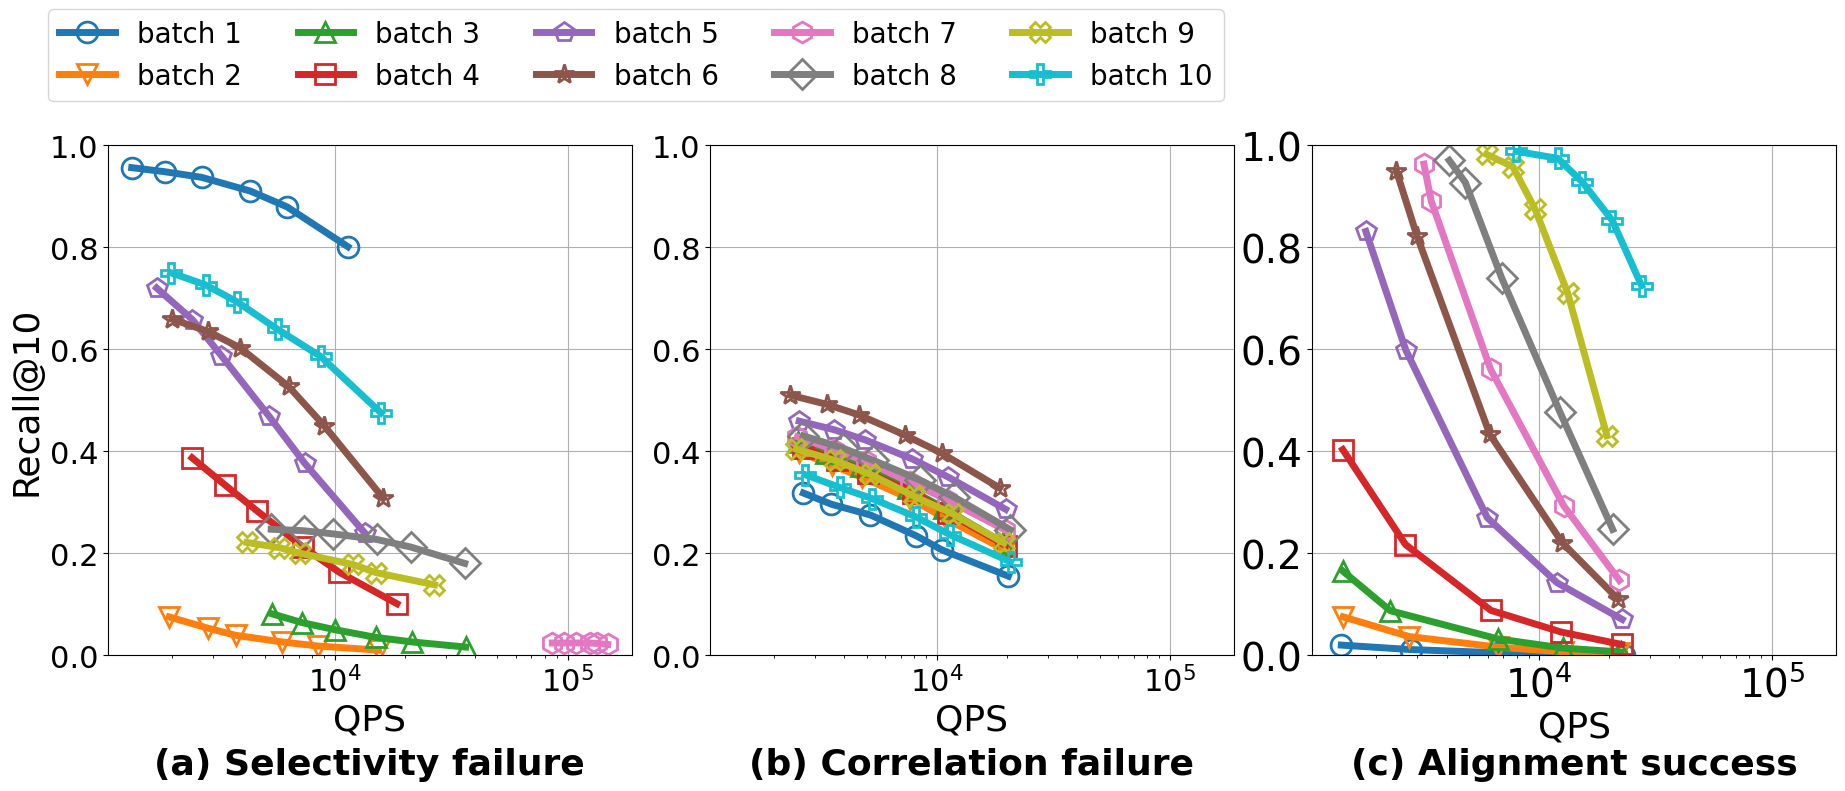

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 두 파일 경로
file_path_1 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/selectivity_search_results.txt"
file_path_2 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/correlation_search_results.txt"
file_path_3 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/post_filter_format/Post_Hardness_search_results.txt"

num = 10
markers = ['o', 'v', '^', 's', 'p', '*', 'h', 'D', 'X', 'P']
batch_labels = [f"batch {i + 1}" for i in range(num)]
colors = plt.cm.get_cmap('tab10', 10)

# subplot 아래 제목 위치
y = -0.18

def load_data(file_path, file_idx):
    qps = [[] for _ in range(num)]
    recall = [[] for _ in range(num)]

    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()[2:]
            for i, line in enumerate(lines):
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    q = int(parts[1].strip())
                    r = float(parts[2].strip())
                    batch_idx = i // 6
                    qps[batch_idx].append(q)
                    recall[batch_idx].append(r)

        if any(qps):
            return qps, recall

    except FileNotFoundError:
        print(f"File not found: {file_path}. Using dummy data.")
        np.random.seed(file_idx)
        for i in range(num):
            qps[i] = list(np.arange(50, 2000, 200))
            recall[i] = list(np.linspace(0.9 - i * 0.03, 0.6 - i * 0.02, len(qps[i])))

    return qps, recall


qps_1, recall_1 = load_data(file_path_1, 1)
qps_2, recall_2 = load_data(file_path_2, 2)
# ------------------ Figure & Subplots ------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# ------------------ (a) Selectivity ------------------
ax1 = axes[0]
for i in range(num):
    ax1.plot(
        qps_1[i], recall_1[i],
        marker=markers[i],
        color=colors(i),
        linewidth=5,
        markersize=15,
        markerfacecolor='none',
        markeredgewidth=2,
        label=batch_labels[i],
    )

ax1.set_xscale("log")
ax1.set_xlabel("QPS", fontsize=26)
ax1.set_ylabel("Recall@10", fontsize=26)
ax1.set_ylim(0, 1)
ax1.tick_params(axis="both", labelsize=22)
ax1.grid(True)

ax1.text(
    0.5, y,
    "(a) Selectivity failure",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    fontsize=26,
    fontweight="bold"
)

# ------------------ (b) Correlation ------------------
ax2 = axes[1]
for i in range(num):
    ax2.plot(
        qps_2[i], recall_2[i],
        marker=markers[i],
        color=colors(i),
        linewidth=5,
        markersize=15,
        markerfacecolor='none',
        markeredgewidth=2,
        label=batch_labels[i],
    )

ax2.set_xscale("log")
ax2.set_xlabel("QPS", fontsize=26)
ax2.set_ylim(0, 1)
ax2.set_xlim(ax1.get_xlim())
ax2.tick_params(axis="both", labelsize=22)
ax2.grid(True)

ax2.text(
    0.5, y,
    "(b) Correlation failure",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    fontsize=26,
    fontweight="bold"
)

# ------------------ (c) Alignment Success ------------------
ax3 = axes[2]
for i in range(num):
    ax3.plot(
        qps_3[i], recall_3[i],
        marker=markers[i],
        color=colors(i),
        linewidth=5,
        markersize=15,
        markerfacecolor='none',
        markeredgewidth=2,
        label=batch_labels[i],
    )

ax3.set_xscale("log")
ax3.set_xlabel("QPS", fontsize=26)
ax3.set_ylim(0, 1)
ax3.set_xlim(ax1.get_xlim())
ax3.tick_params(axis="both", labelsize=28)
ax3.grid(True)

ax3.text(
    0.5, y,
    "(c) Alignment success",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=26,
    fontweight="bold"
)

# ------------------ Legend ------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    fontsize=20,
    bbox_to_anchor=(0.50, 1.1)
)

# ------------------ Layout & Save ------------------
plt.tight_layout()
plt.subplots_adjust(
    left=0.06,   # 좌측 여백 (필요 없으면 그대로 둬도 됨)
    right=1.5,  # 우측 여백
    top=0.85,    # legend 때문에 상승한 범위 보정 필요시
    bottom=0.0, # x축 레이블 공간
    wspace=0.15, # 👈 서브플롯 좌우 간격 (0.15~0.45 사이 추천)
    hspace=0.1  # 👈 위아래 간격 (1행이라 크긴하지만 안전하게)
)

pdf_path = "factors_fail.pdf"
plt.savefig(pdf_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()


/tmp/ipykernel_653900/2131001682.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


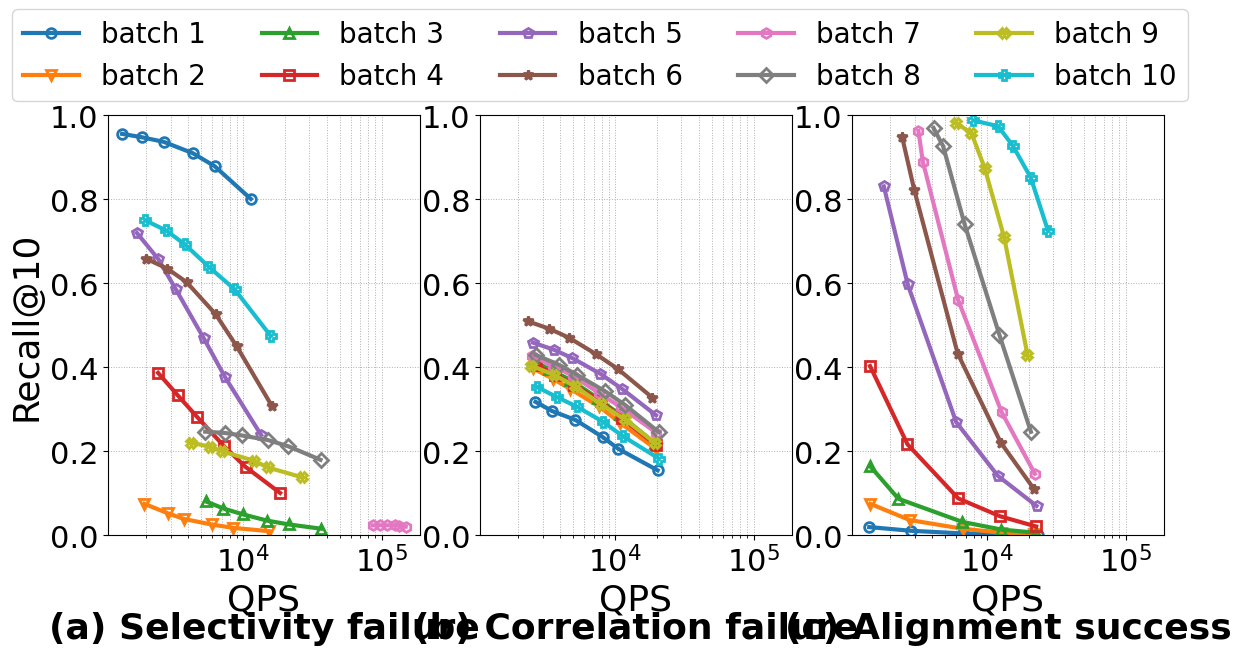

[Saved] factors_fail_fixed.pdf


In [109]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------ 파일 경로 ------------------
file_path_1 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/selectivity_search_results.txt"
file_path_2 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/correlation_search_results.txt"
file_path_3 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/post_filter_format/Post_Hardness_search_results.txt"

num = 10
markers = ['o', 'v', '^', 's', 'p', '*', 'h', 'D', 'X', 'P']
batch_labels = [f"batch {i + 1}" for i in range(num)]
colors = plt.cm.get_cmap('tab10', 10)

# subplot 아래 제목 위치 (axes 좌표계 기준)
y = -0.18

# ------------------ 데이터 로더 ------------------
def load_data(file_path, file_idx):
    qps = [[] for _ in range(num)]
    recall = [[] for _ in range(num)]

    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()[2:]
            for i, line in enumerate(lines):
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    q = int(parts[1].strip())
                    r = float(parts[2].strip())
                    batch_idx = i // 6
                    qps[batch_idx].append(q)
                    recall[batch_idx].append(r)

        if any(qps):
            return qps, recall

    except FileNotFoundError:
        print(f"File not found: {file_path}. Using dummy data.")
        np.random.seed(file_idx)
        for i in range(num):
            qps[i] = list(np.arange(1000, 20000, 2000))
            recall[i] = list(np.linspace(0.95 - i*0.07, 0.4 - i*0.05, len(qps[i])))

    return qps, recall

qps_1, recall_1 = load_data(file_path_1, 1)
qps_2, recall_2 = load_data(file_path_2, 2)
# qps_3, recall_3 = load_data(file_path_3, 3)

# ------------------ Figure & Axes (add_axes로 고정) ------------------
fig = plt.figure(figsize=(12, 6))

# [left, bottom, width, height]
ax1 = fig.add_axes([0.06, 0.18, 0.26, 0.70])
ax2 = fig.add_axes([0.37, 0.18, 0.26, 0.70])
ax3 = fig.add_axes([0.68, 0.18, 0.26, 0.70])

# ------------------ (a) Selectivity ------------------
for i in range(num):
    ax1.plot(
        qps_1[i], recall_1[i],
        marker=markers[i],
        color=colors(i),
        linewidth=3,
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=2,
        label=batch_labels[i],
    )

ax1.set_xscale("log")
ax1.set_xlabel("QPS", fontsize=26)
ax1.set_ylabel("Recall@10", fontsize=26)
ax1.set_ylim(0, 1)
ax1.tick_params(axis="both", labelsize=22)
ax1.grid(True, which="both", linestyle=":", linewidth=0.7)

ax1.text(
    0.5, y,
    "(a) Selectivity failure",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    fontsize=26,
    fontweight="bold"
)

# ------------------ (b) Correlation ------------------
for i in range(num):
    ax2.plot(
        qps_2[i], recall_2[i],
        marker=markers[i],
        color=colors(i),
        linewidth=3,
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=2,
        label=batch_labels[i],
    )

ax2.set_xscale("log")
ax2.set_xlabel("QPS", fontsize=26)
ax2.set_ylim(0, 1)
ax2.set_xlim(ax1.get_xlim())
ax2.tick_params(axis="both", labelsize=22)
ax2.grid(True, which="both", linestyle=":", linewidth=0.7)

ax2.text(
    0.5, y,
    "(b) Correlation failure",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    fontsize=26,
    fontweight="bold"
)

# ------------------ (c) Alignment Success ------------------
for i in range(num):
    ax3.plot(
        qps_3[i], recall_3[i],
        marker=markers[i],
        color=colors(i),
        linewidth=3,
        markersize=7,
        markerfacecolor='none',
        markeredgewidth=2,
        label=batch_labels[i],
    )

ax3.set_xscale("log")
ax3.set_xlabel("QPS", fontsize=26)
ax3.set_ylim(0, 1)
ax3.set_xlim(ax1.get_xlim())
ax3.tick_params(axis="both", labelsize=22)
ax3.grid(True, which="both", linestyle=":", linewidth=0.7)

ax3.text(
    0.5, y,
    "(c) Alignment success",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=26,
    fontweight="bold"
)

# ------------------ Legend (figure 기준) ------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    fontsize=20,
    bbox_to_anchor=(0.470, 1.08)
)

# ------------------ Save ------------------
out_path = "factors_fail_fixed.pdf"
plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()
print(f"[Saved] {out_path}")


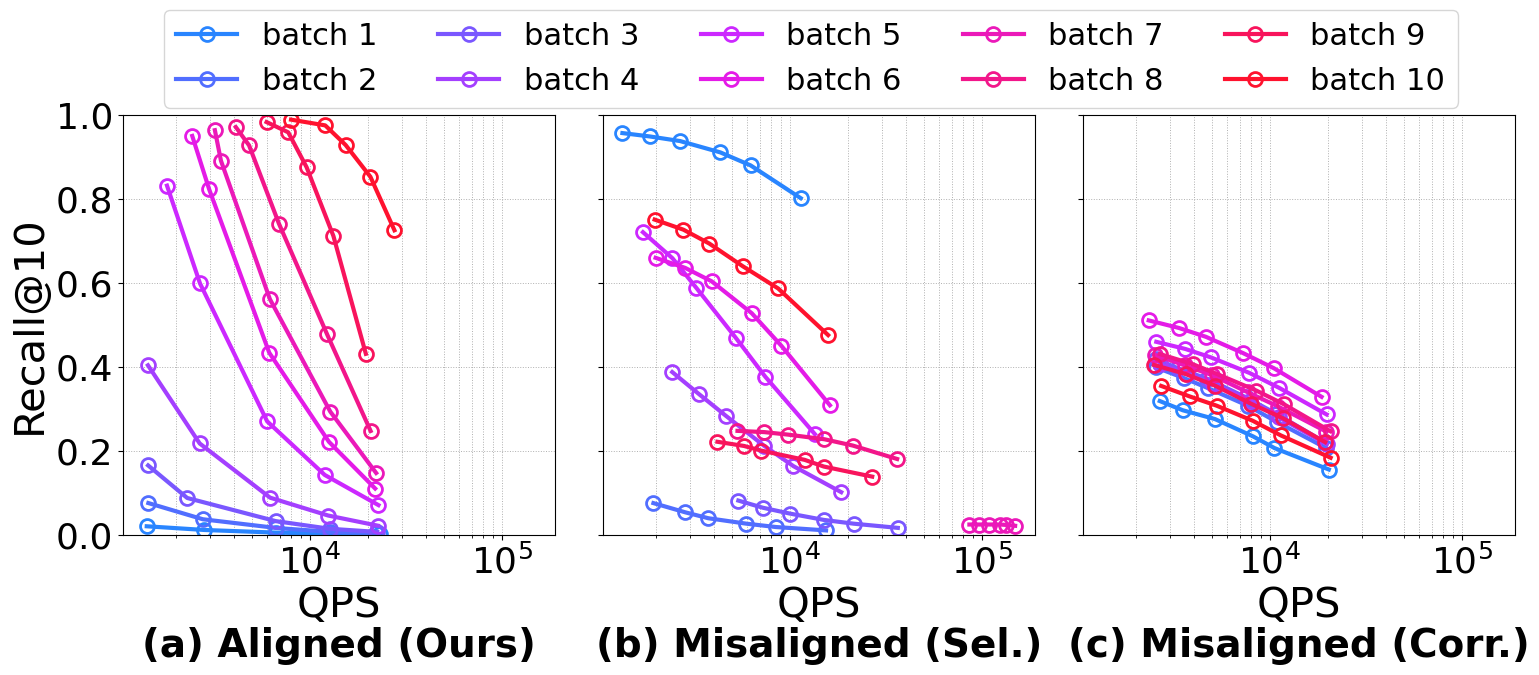

[Saved] factors_fail_fixed_color.pdf


In [180]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import LinearSegmentedColormap

# ------------------ 파일 경로 ------------------
file_path_1 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/selectivity_search_results.txt"
file_path_2 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/correlation_search_results.txt"
file_path_3 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/post_filter_format/Post_Hardness_search_results.txt"

num = 10
markers = ['o'] * 20
batch_labels = [f"batch {i + 1}" for i in range(num)]
# colors = plt.cm.get_cmap('tab10', 10)

cmap = LinearSegmentedColormap.from_list(
    "blue_purple_red",
    ["#2985ff", "#e11cff", "#ff122e"]  # blue → purple → red
)
colors = [cmap(i / (num - 1)) for i in range(num)]


# subplot 아래 제목 위치
y = -0.18

# ------------------ 데이터 로더 ------------------
def load_data(file_path, file_idx):
    qps = [[] for _ in range(num)]
    recall = [[] for _ in range(num)]

    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()[2:]
            for i, line in enumerate(lines):
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    q = int(parts[1].strip())
                    r = float(parts[2].strip())
                    batch_idx = i // 6
                    qps[batch_idx].append(q)
                    recall[batch_idx].append(r)

        if any(qps):
            return qps, recall

    except FileNotFoundError:
        print(f"File not found: {file_path}. Using dummy data.")
        np.random.seed(file_idx)
        for i in range(num):
            qps[i] = list(np.arange(1000, 20000, 2000))
            recall[i] = list(np.linspace(0.95 - i*0.07, 0.4 - i*0.05, len(qps[i])))

    return qps, recall

qps_1, recall_1 = load_data(file_path_1, 1)
qps_2, recall_2 = load_data(file_path_2, 2)
# qps_3, recall_3 = load_data(file_path_3, 3)

# ------------------ Figure & Axes ------------------
fig = plt.figure(figsize=(16, 6))

# (좌측 여백 유지, subplot 폭 조금 줄여 간격 좁힘)
ax1 = fig.add_axes([0.07, 0.18, 0.27, 0.70])
ax2 = fig.add_axes([0.37, 0.18, 0.27, 0.70])
ax3 = fig.add_axes([0.67, 0.18, 0.27, 0.70])

# ------------------ helper function ------------------
def plot_panel(ax, qps_data, recall_data, title):
    for i in range(num):
        ax.plot(
            qps_data[i], recall_data[i],
            marker=markers[i],
            color=colors[i],
            linewidth=3,
            markersize=10,
            markerfacecolor='none',
            markeredgewidth=2,
            label=batch_labels[i],
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7)

    ax.text(
        0.5, -0.22,
        title,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=28,
        fontweight="bold"
    )

# ------------------ (a) Selectivity ------------------
plot_panel(ax1, qps_3, recall_3, "(a) Aligned (Ours)")
ax1.set_xlabel("QPS", fontsize=30)
ax1.set_ylabel("Recall@10", fontsize=30)
ax1.tick_params(axis="both", labelsize=26)

# ------------------ (b) Correlation ------------------
plot_panel(ax2, qps_1, recall_1, "(b) Misaligned (Sel.)")
ax2.set_xlabel("QPS", fontsize=30)
# ax2.set_xlim(ax1.get_xlim())
ax2.tick_params(axis="both", labelsize=26)

# y축 label / ticks 제거
ax2.set_ylabel("")
ax2.set_yticklabels([])

# ------------------ (c) Alignment success ------------------
plot_panel(ax3, qps_2, recall_2, "(c) Misaligned (Corr.)")
ax3.set_xlabel("QPS", fontsize=30)
ax3.set_xlim(ax2.get_xlim())
ax3.tick_params(axis="both", labelsize=26)

ax3.set_ylabel("")
ax3.set_yticklabels([])

# ------------------ Legend ------------------
ax1.set_xlim(ax2.get_xlim())

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    fontsize=22,
    bbox_to_anchor=(0.50, 1.08)
)

# ------------------ Save ------------------
out_path = "factors_fail_fixed_color.pdf"
plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()
print(f"[Saved] {out_path}")


In [181]:
print(1)

1


/tmp/ipykernel_653900/4027476411.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)
/tmp/ipykernel_653900/4027476411.py:125: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


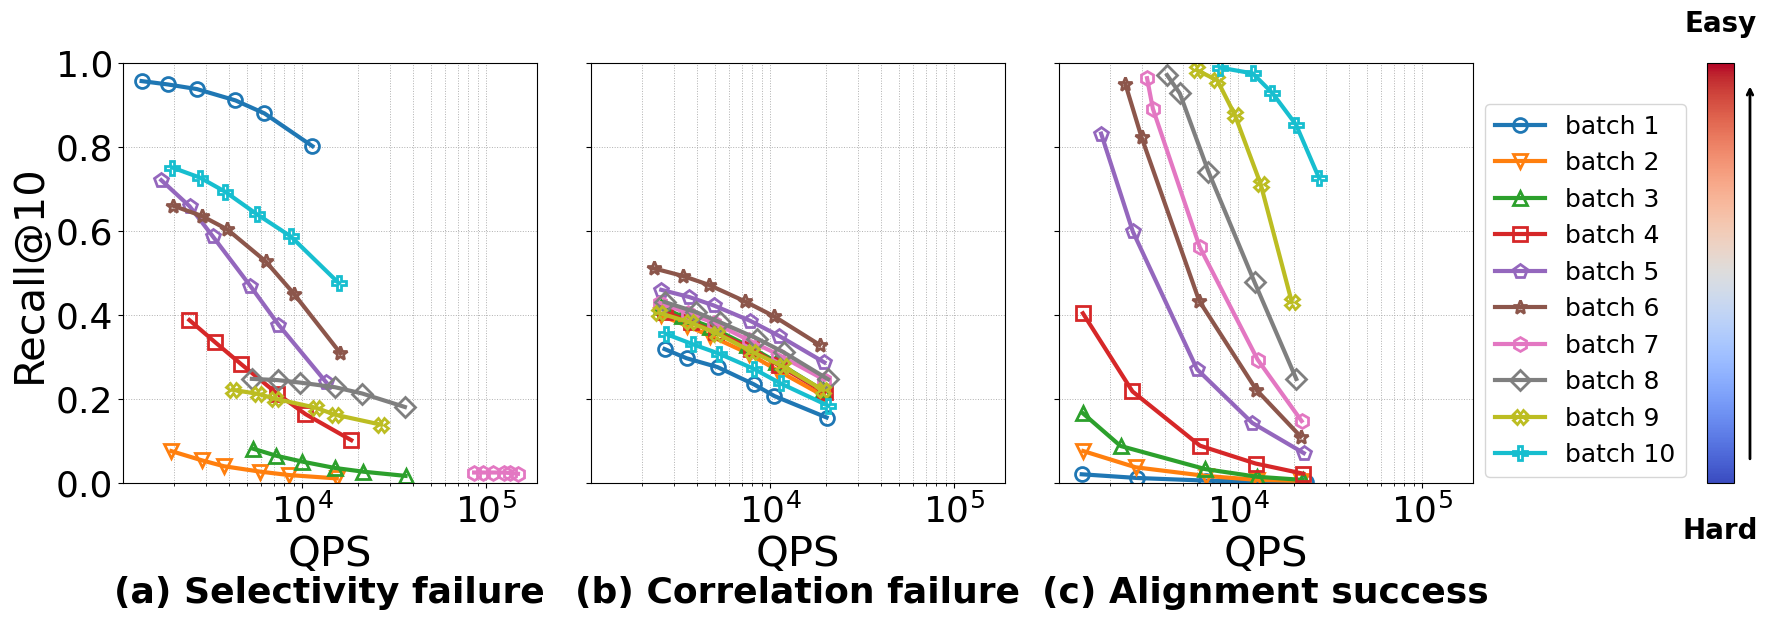

[Saved] factors_fail_fixed.pdf


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# ------------------ 파일 경로 ------------------
file_path_1 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/selectivity_search_results.txt"
file_path_2 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/correlation_search_results.txt"
file_path_3 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/post_filter_format/Post_Hardness_search_results.txt"

num = 10
markers = ['o', 'v', '^', 's', 'p', '*', 'h', 'D', 'X', 'P']
batch_labels = [f"batch {i + 1}" for i in range(num)]
colors = plt.cm.get_cmap('tab10', 10)

# ------------------ 데이터 로더 ------------------
def load_data(file_path, file_idx):
    qps = [[] for _ in range(num)]
    recall = [[]"#f8c9ff" range(num)]

    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()[2:]
            for i, line in enumerate(lines):
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    q = int(parts[1].strip())
                    r = float(parts[2].strip())
                    batch_idx = i // 6
                    if batch_idx < num:
                        qps[batch_idx].append(q)
                        recall[batch_idx].append(r)

        if any(len(x) > 0 for x in qps):
            return qps, recall

    except FileNotFoundError:
        print(f"File not found: {file_path}. Using dummy data.")
        np.random.seed(file_idx)
        for i in range(num):
            qps[i] = list(np.arange(1000, 20000, 2000))
            recall[i] = list(np.linspace(0.95 - i*0.07, 0.4 - i*0.05, len(qps[i])))

    return qps, recall

qps_1, recall_1 = load_data(file_path_1, 1)
qps_2, recall_2 = load_data(file_path_2, 2)
# qps_3, recall_3 = load_data(file_path_3, 3)

# ------------------ Figure & Axes ------------------
# 오른쪽에 legend+colorbar 들어갈 공간 확보를 위해 폭을 좀 넉넉히
fig = plt.figure(figsize=(18, 6))

# 3개 패널을 왼쪽에 모아두고, 오른쪽에 legend/cbar 공간 남김
ax1 = fig.add_axes([0.06, 0.18, 0.23, 0.70])
ax2 = fig.add_axes([0.32, 0.18, 0.23, 0.70])
ax3 = fig.add_axes([0.58, 0.18, 0.23, 0.70])

# ------------------ helper function ------------------
def plot_panel(ax, qps_data, recall_data, title):
    for i in range(num):
        ax.plot(
            qps_data[i], recall_data[i],
            marker=markers[i],
            color=colors(i),
            linewidth=3,
            markersize=10,
            markerfacecolor='none',
            markeredgewidth=2,
            label=batch_labels[i],
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7)

    ax.text(
        0.5, -0.22,
        title,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=26,
        fontweight="bold"
    )

# ------------------ (a) Selectivity ------------------
plot_panel(ax1, qps_1, recall_1, "(a) Selectivity failure")
ax1.set_xlabel("QPS", fontsize=30)
ax1.set_ylabel("Recall@10", fontsize=30)
ax1.tick_params(axis="both", labelsize=26)

# ------------------ (b) Correlation ------------------
plot_panel(ax2, qps_2, recall_2, "(b) Correlation failure")
ax2.set_xlabel("QPS", fontsize=30)
ax2.set_xlim(ax1.get_xlim())
ax2.tick_params(axis="both", labelsize=26)
ax2.set_ylabel("")
ax2.set_yticklabels([])

# ------------------ (c) Alignment success ------------------
plot_panel(ax3, qps_3, recall_3, "(c) Alignment success")
ax3.set_xlabel("QPS", fontsize=30)
ax3.set_xlim(ax1.get_xlim())
ax3.tick_params(axis="both", labelsize=26)
ax3.set_ylabel("")
ax3.set_yticklabels([])

# ------------------ Legend: 오른쪽 1컬럼 ------------------
handles, labels = ax1.get_legend_handles_labels()

# legend를 오른쪽에 "1 column"으로 고정
fig.legend(
    handles,
    labels,
    loc="center left",
    ncol=1,
    fontsize=18,
    # frameon=False,
    bbox_to_anchor=(0.81, 0.5)  # (x, y) in figure coords
)

# ------------------ Gradient bar + Easy/Hard + Arrow ------------------
cbar_ax = fig.add_axes([0.94, 0.18, 0.015, 0.70])  # [left, bottom, width, height]

# 그라데이션 (위=Easy, 아래=Hard)
cmap = mpl.cm.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
cbar.set_ticks([])
cbar.outline.set_linewidth(0.8)

# ------------------ Easy / Hard 텍스트 (바 위/아래) ------------------
cbar_ax.text(
    0.5, 1.06, "Easy",
    transform=cbar_ax.transAxes,
    ha="center", va="bottom",
    fontsize=20, fontweight="bold"
)

cbar_ax.text(
    0.5, -0.08, "Hard",
    transform=cbar_ax.transAxes,
    ha="center", va="top",
    fontsize=20, fontweight="bold"
)

# ------------------ 방향 화살표 ------------------
# 아래 -> 위 (Hard -> Easy)
cbar_ax.annotate(
    "",
    xy=(1.6, 0.95),     # arrow head (top)
    xytext=(1.6, 0.05), # arrow tail (bottom)
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2.0,
        color="black"
    )
)

# ------------------ Save ------------------
out_path = "factors_fail_fixed.pdf"
plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()
print(f"[Saved] {out_path}")


/tmp/ipykernel_653900/583862845.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


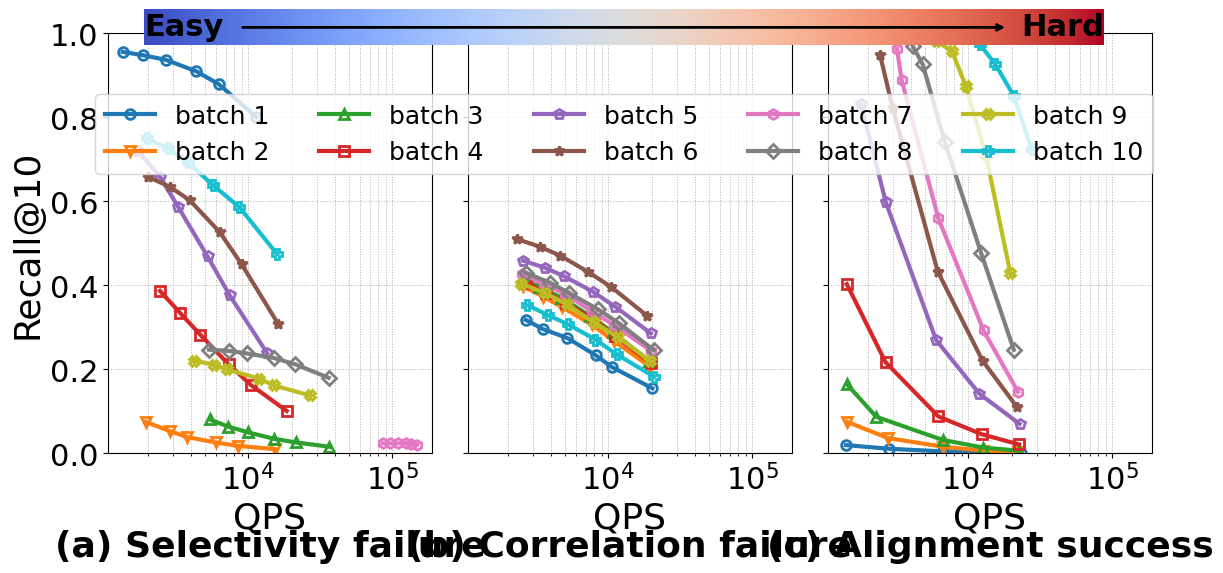

[Saved] factors_fail_with_bar.pdf


In [134]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------ 파일 경로 ------------------
file_path_1 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/selectivity_search_results.txt"
file_path_2 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/rwalks_format/correlation_search_results.txt"
file_path_3 = "/home/ec2-user/hybrid_hardness/Benchmark/sift1m_A3_6_6_6_zipf_0.5_0.5_0.5_0.0_0.0_0.0/post_filter_format/Post_Hardness_search_results.txt"

num = 10
markers = ['o', 'v', '^', 's', 'p', '*', 'h', 'D', 'X', 'P']
batch_labels = [f"batch {i + 1}" for i in range(num)]
colors = plt.cm.get_cmap('tab10', 10)

# subplot 아래 제목 위치
TITLE_Y = -0.18

# ------------------ 데이터 로더 ------------------
def load_data(file_path, file_idx):
    qps = [[] for _ in range(num)]
    recall = [[] for _ in range(num)]

    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()[2:]
            for i, line in enumerate(lines):
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    q = int(parts[1].strip())
                    r = float(parts[2].strip())
                    batch_idx = i // 6
                    qps[batch_idx].append(q)
                    recall[batch_idx].append(r)

        if any(qps):
            return qps, recall

    except FileNotFoundError:
        print(f"File not found: {file_path}. Using dummy data.")
        np.random.seed(file_idx)
        for i in range(num):
            qps[i] = list(np.arange(1000, 20000, 2000))
            recall[i] = list(np.linspace(0.95 - i*0.07, 0.4 - i*0.05, len(qps[i])))

    return qps, recall

qps_1, recall_1 = load_data(file_path_1, 1)
qps_2, recall_2 = load_data(file_path_2, 2)
# qps_3, recall_3 = load_data(file_path_3, 3)

# ------------------ Figure & Axes ------------------
fig = plt.figure(figsize=(12, 6))

# 메인 서브플롯들 (절대좌표)
ax1 = fig.add_axes([0.07, 0.18, 0.27, 0.70])
ax2 = fig.add_axes([0.37, 0.18, 0.27, 0.70])
ax3 = fig.add_axes([0.67, 0.18, 0.27, 0.70])

# ------------------ helper function ------------------
def plot_panel(ax, qps_data, recall_data, title):
    for i in range(num):
        ax.plot(
            qps_data[i], recall_data[i],
            marker=markers[i],
            color=colors(i),
            linewidth=3,
            markersize=7,
            markerfacecolor='none',
            markeredgewidth=2,
            label=batch_labels[i],
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7)

    ax.text(
        0.5, TITLE_Y,
        title,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=26,
        fontweight="bold"
    )

# ------------------ (a) Selectivity ------------------
plot_panel(ax1, qps_1, recall_1, "(a) Selectivity failure")
ax1.set_xlabel("QPS", fontsize=26)
ax1.set_ylabel("Recall@10", fontsize=26)
ax1.tick_params(axis="both", labelsize=22)

# ------------------ (b) Correlation ------------------
plot_panel(ax2, qps_2, recall_2, "(b) Correlation failure")
ax2.set_xlabel("QPS", fontsize=26)
ax2.set_xlim(ax1.get_xlim())
ax2.tick_params(axis="both", labelsize=22)
ax2.set_ylabel("")
ax2.set_yticklabels([])

# ------------------ (c) Alignment success ------------------
plot_panel(ax3, qps_3, recall_3, "(c) Alignment success")
ax3.set_xlabel("QPS", fontsize=26)
ax3.set_xlim(ax1.get_xlim())
ax3.tick_params(axis="both", labelsize=22)
ax3.set_ylabel("")
ax3.set_yticklabels([])

# ------------------ 위쪽 Easy–Hard 그라데이션 바 ------------------
# 새로운 얇은 axes 추가 (전체 폭)
bar_ax = fig.add_axes([0.10, 0.86, 0.80, 0.06])   # [left, bottom, width, height]

# 0~1 horizontal gradient
gradient = np.linspace(0, 1, 512).reshape(1, -1)
# blue -> red colormap (원하면 'coolwarm', 'bwr' 등으로 바꿀 수 있음)
bar_ax.imshow(gradient, aspect="auto", cmap="coolwarm")
bar_ax.set_axis_off()  # 축/테두리 제거

# 텍스트 & 화살표
# Easy (왼쪽)
bar_ax.text(
    0.0, 0.5, "Easy",
    transform=bar_ax.transAxes,
    ha="left", va="center",
    fontsize=22, fontweight="bold"
)
# Hard (오른쪽)
bar_ax.text(
    1.0, 0.5, "Hard",
    transform=bar_ax.transAxes,
    ha="right", va="center",
    fontsize=22, fontweight="bold"
)

# 원하면 화살표도 추가 (옵션)
bar_ax.annotate(
    "", xy=(0.90, 0.5), xytext=(0.10, 0.5),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="->", linewidth=2, color="black")
)

# ------------------ Legend ------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    fontsize=18,
    bbox_to_anchor=(0.50, 0.80)  # 바 아래 정도로 살짝 내려서 배치
)

# ------------------ Save ------------------
out_path = "factors_fail_with_bar.pdf"
fig.savefig(out_path, dpi=300, pad_inches=0)   # tight 쓰지 말 것
plt.show()
print(f"[Saved] {out_path}")
